# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
data_jobs = pd.read_csv('../data/raw/data_jobs_norm.csv')
data_jobs.head(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,seniority,job_title_unified
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,Senior,Data Engineer
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",Junior/Mid,Data Analyst
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",Junior/Mid,Data Engineer
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",Junior/Mid,Data Engineer
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",Junior/Mid,Data Engineer
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",Junior/Mid,Data Engineer
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",Senior,Data Engineer
7,Data Engineer,Data Engineer,Anywhere,via LinkedIn,Full-time,True,Romania,2023-12-07 13:40:49,False,False,Romania,NaN,NaN,NaN,Zitec,"['sql', 'nosql', 'gcp', 'azure', 'aws', 'bigqu...","{'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...",Junior/Mid,Data Engineer
8,Business Analyst,Technology & Operations Business Analyst,"Copenhagen, Denmark",via Trabajo.org,Full-time,False,Denmark,2023-06-05 13:44:34,False,False,Denmark,NaN,NaN,NaN,Hempel,"['excel', 'powerpoint', 'power bi']","{'analyst_tools': ['excel', 'powerpoint', 'pow...",Junior/Mid,Business Analyst
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",Junior/Mid,Data Scientist


In [5]:
data_jobs.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  str    
 1   job_title              785740 non-null  str    
 2   job_location           784696 non-null  str    
 3   job_via                785733 non-null  str    
 4   job_schedule_type      773074 non-null  str    
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  str    
 7   job_posted_date        785741 non-null  str    
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  str    
 11  salary_rate            33067 non-null   str    
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-null  str    

In [4]:
# Transforming the 'job_posted_date' column to datetime format for time series analysis
data_jobs['job_posted_date'] = pd.to_datetime(data_jobs['job_posted_date'])

In [5]:
# Grouping the data by job title and week to get the count of vacancies per week for each job title
df_weekly = data_jobs.groupby(['job_title_unified', pd.Grouper(key='job_posted_date', freq='W')]).size().reset_index(name='vacancy_count')
# DataFrame with weekly aggregated vacancy counts for each job title
df_weekly

,job_title_unified,job_posted_date,vacancy_count
0,Business Analyst,2023-01-01,182
1,Business Analyst,2023-01-08,1060
2,Business Analyst,2023-01-15,1119
3,Business Analyst,2023-01-22,1156
4,Business Analyst,2023-01-29,1047
...,...,...,...
366,Software Engineer,2023-12-03,841
367,Software Engineer,2023-12-10,1032
368,Software Engineer,2023-12-17,899
369,Software Engineer,2023-12-24,817


In [40]:
df_weekly.describe()

,job_posted_date,vacancy_count
count,371,371.000000
mean,2023-07-02 00:00:00,2117.900270
min,2023-01-01 00:00:00,49.000000
25%,2023-04-02 00:00:00,307.000000
50%,2023-07-02 00:00:00,1060.000000
75%,2023-10-01 00:00:00,4089.500000
max,2023-12-31 00:00:00,6273.000000
std,NaN,1903.604876


In [ ]:
# Checking for missing weeks in the data
full_range = pd.date_range(start=df_weekly['job_posted_date'].min(), end=df_weekly['job_posted_date'].max(), freq='W')
diff = full_range.difference(df_weekly['job_posted_date'])
print(f'Пропущено: {diff.shape[0]} дней')

Пропущено: 0 дней


In [ ]:
# Weekly aggregated data without job title specification
weekly_no_spec = df_weekly.groupby('job_posted_date').agg({'vacancy_count': 'sum'}).reset_index()
weekly_no_spec['MONTH'] = weekly_no_spec['job_posted_date'].dt.month
weekly_no_spec['YEAR'] = weekly_no_spec['job_posted_date'].dt.year
weekly_no_spec['DAY_OF_WEEK'] = weekly_no_spec['job_posted_date'].dt.dayofweek
weekly_no_spec['QUARTER'] = weekly_no_spec['job_posted_date'].dt.quarter

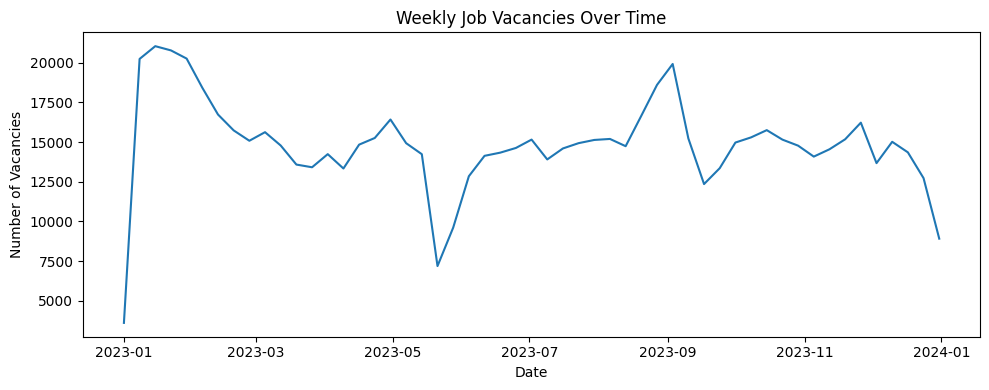

In [ ]:
# Visualizing the weekly job vacancies over time
plt.figure(figsize=(10, 4))
sns.lineplot(data=weekly_no_spec, x='job_posted_date', y='vacancy_count')
plt.title('Weekly Job Vacancies Over Time')
plt.ylabel('Number of Vacancies')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

Demand increase in January, decrease in May-June and increase again in September

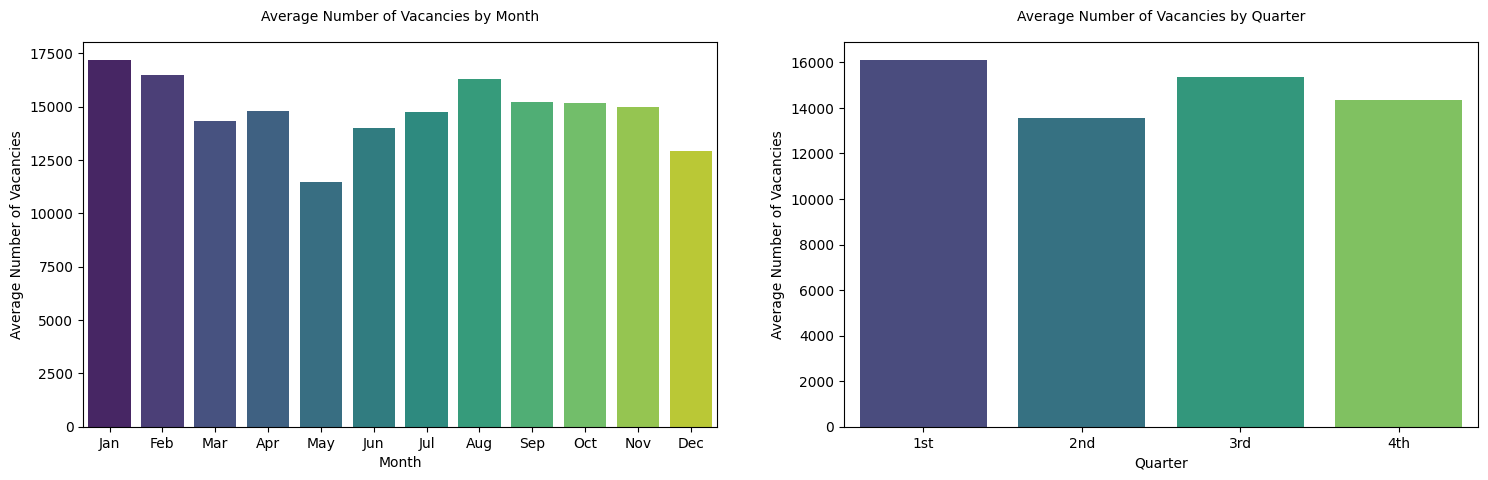

In [23]:
# Analyzing the average number of vacancies by month and quarter
monthly_avg = weekly_no_spec.groupby('MONTH')['vacancy_count'].mean().reset_index()
quarterly_avg = weekly_no_spec.groupby('QUARTER')['vacancy_count'].mean().reset_index()
# Visualizing the average number of vacancies by month and quarter
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(data=monthly_avg, x='MONTH', y='vacancy_count', ax=axes[0], palette='viridis')
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].set_title('Average Number of Vacancies by Month', fontsize=10, pad=15)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Number of Vacancies')
sns.barplot(data=quarterly_avg, x='QUARTER', y='vacancy_count', ax=axes[1], palette='viridis')
axes[1].set_xticklabels(['1st', '2nd', '3rd', '4th'])
axes[1].set_title('Average Number of Vacancies by Quarter', fontsize=10, pad=15)
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Average Number of Vacancies')
plt.show()

Same patern with peaks at start of the year and in August-September

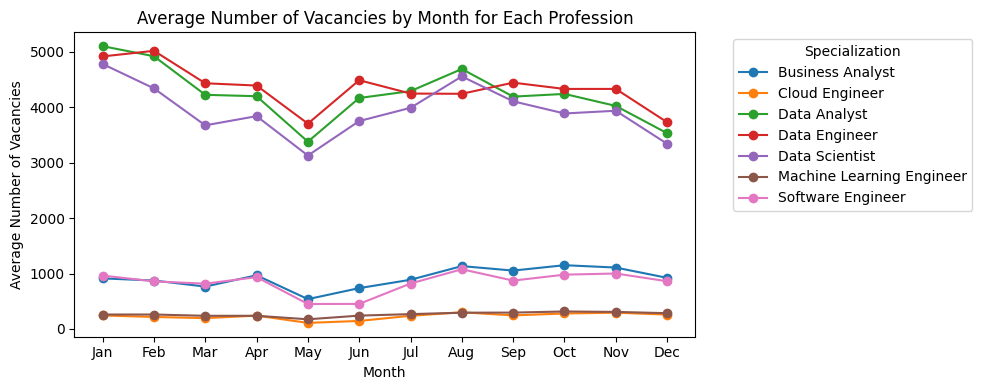

In [ ]:
# Analyzing the average number of vacancies by month for each profession
weekly_df_copy = df_weekly.copy()
weekly_df_copy.rename(columns={'job_title_unified': 'specialization'}, inplace=True)
weekly_df_copy['MONTH'] = weekly_df_copy['job_posted_date'].dt.month
pivot = weekly_df_copy.pivot_table(index='MONTH', values='vacancy_count', aggfunc='mean', columns='specialization')
# Visualizing the average number of vacancies by month for each profession
pivot.plot(kind='line', marker='o', figsize=(10, 4))
plt.title('Average Number of Vacancies by Month for Each Profession')
plt.xlabel('Month')
plt.ylabel('Average Number of Vacancies')
plt.xticks(ticks=np.arange(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Specialization', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Data Engineer, Data Scientist, Data Analyst outnumber other specializations

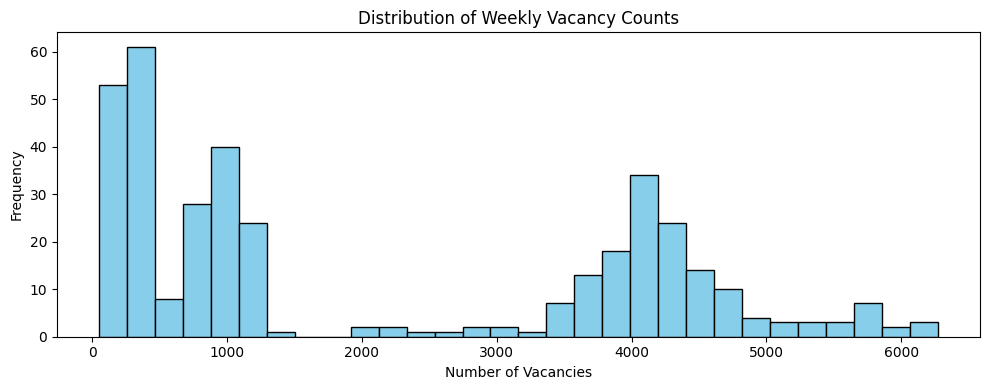

In [33]:
# Visualizing the distribution of weekly vacancy counts
plt.figure(figsize=(10, 4))
plt.hist(df_weekly['vacancy_count'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Weekly Vacancy Counts')
plt.xlabel('Number of Vacancies')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Distribution looks like this because of superiority of Data Engineer, Data Scientist, Data Analyst

In [ ]:
# Checking for stationarity using ADF test
result = adfuller(weekly_no_spec.set_index('job_posted_date')['vacancy_count'])
print(f'ADF statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
print('Stationary series' if result[1] < 0.05 else 'Non-stationary series')

ADF statistic: -3.2783, p-value: 0.0159
Stationary series


Stationary series means statistical properties throughout time-series will be kept

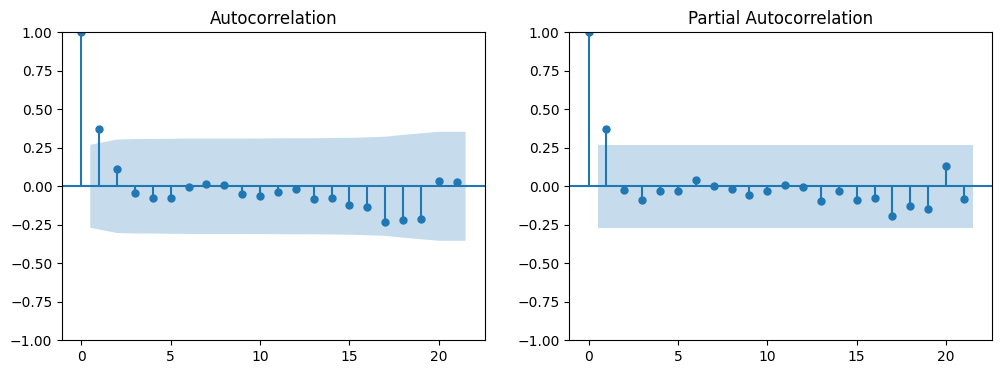

In [ ]:
# Analyzing autocorrelation and partial autocorrelation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(weekly_no_spec.set_index('job_posted_date')['vacancy_count'], lags=21, ax=axes[0])
plot_pacf(weekly_no_spec.set_index('job_posted_date')['vacancy_count'], lags=21, ax=axes[1])
plt.show()

lag_1 and lag_2 are the most influential. Series with short memory

Outliers: 11


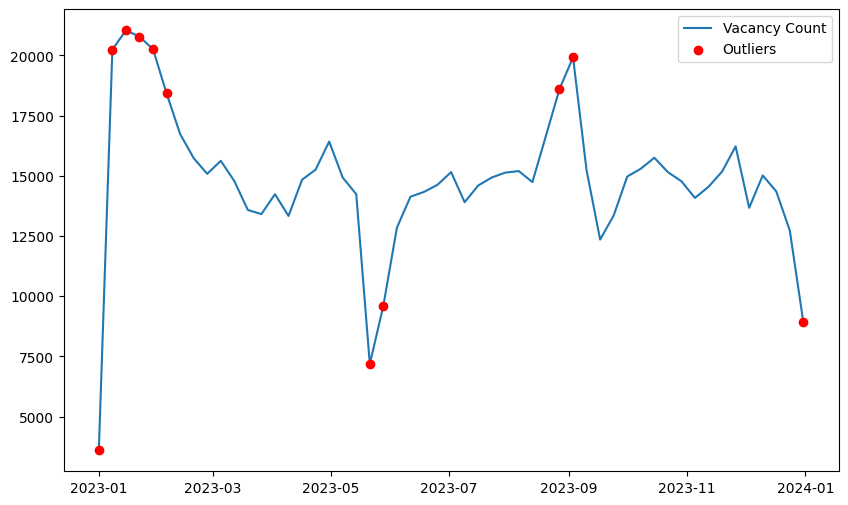

In [50]:
# Identifying outliers using the IQR method
Q1 = weekly_no_spec['vacancy_count'].quantile(0.25)
Q3 = weekly_no_spec['vacancy_count'].quantile(0.75)
IQR = Q3 - Q1
outliers = weekly_no_spec[(weekly_no_spec['vacancy_count'] < Q1 - 1.5 * IQR) | (weekly_no_spec['vacancy_count'] > Q3 + 1.5 * IQR)]
print(f'Outliers: {len(outliers)}')
plt.figure(figsize=(10, 6))
plt.plot(weekly_no_spec['job_posted_date'], weekly_no_spec['vacancy_count'], label='Vacancy Count')
plt.scatter(outliers['job_posted_date'], outliers['vacancy_count'], color='red', label='Outliers', zorder=5)
plt.legend()
plt.show()

In [51]:
# Displaying the outliers with their corresponding dates and vacancy counts
print(outliers[['job_posted_date', 'vacancy_count']].sort_values(by='vacancy_count', ascending=False).head(10))

   job_posted_date  vacancy_count
2       2023-01-15          21045
3       2023-01-22          20778
4       2023-01-29          20262
1       2023-01-08          20241
35      2023-09-03          19923
34      2023-08-27          18604
5       2023-02-05          18425
21      2023-05-28           9606
52      2023-12-31           8912
20      2023-05-21           7185


# Conclusion

The exploratory data analysis of the job vacancies time series revealed the following key findings:

## Temporal Patterns and Seasonality

Hiring demand follows a clear seasonal cycle: activity peaks in **January** and again in **August–September**, while **May–June** consistently show a notable decline in postings. This pattern holds at both the monthly and quarterly levels.

## Dominant Specializations

Three roles — **Data Engineer**, **Data Scientist**, and **Data Analyst** — account for the vast majority of vacancies, significantly outpacing all other specializations. Their dominance directly shapes the right-skewed distribution of weekly vacancy counts.

## Stationarity

The Augmented Dickey–Fuller (ADF) test confirmed that the series is **stationary** (p-value < 0.05), meaning its statistical properties — mean and variance — remain stable over time. This is a favorable property for applying classical forecasting methods without additional differencing.

## Autocorrelation Structure

ACF and PACF analysis indicated that **lag 1** and **lag 2** are the most influential predictors of current values. The series exhibits **short memory**, with autocorrelation decaying rapidly — limiting the effective autoregressive order needed for modeling.

## Outliers

The IQR method identified several weeks with anomalously high vacancy counts, concentrated around peak hiring periods. These observations should be accounted for in modeling — either through smoothing or by introducing binary spike indicators.

## Recommendations

The series' stationarity, short memory, and seasonal peaks make it well-suited for **ARIMA/SARIMA** models or machine learning approaches with lagged features. Outliers should be handled explicitly to prevent them from distorting model training and evaluation.